In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Load dataset & drop
df = pd.read_csv("data/data.csv")

print("All columns:")
print(df.columns)

cols_to_drop = ["CASE_NO_PATIENT'S", 'Who_completed_the_test', 'Ethnicity', 'Jaundice']

df = df.drop(columns=cols_to_drop)

print("\nColumns after dropping irrelevant ones:")
print(df.columns)

All columns:
Index(['CASE_NO_PATIENT'S', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8',
       'A9', 'A10_Autism_Spectrum_Quotient', 'Social_Responsiveness_Scale',
       'Age_Years', 'Qchat_10_Score', 'Speech Delay/Language Disorder',
       'Learning disorder', 'Genetic_Disorders', 'Depression',
       'Global developmental delay/intellectual disability',
       'Social/Behavioural Issues', 'Childhood Autism Rating Scale',
       'Anxiety_disorder', 'Sex', 'Ethnicity', 'Jaundice',
       'Family_mem_with_ASD', 'Who_completed_the_test', 'ASD_traits'],
      dtype='str')

Columns after dropping irrelevant ones:
Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9',
       'A10_Autism_Spectrum_Quotient', 'Social_Responsiveness_Scale',
       'Age_Years', 'Qchat_10_Score', 'Speech Delay/Language Disorder',
       'Learning disorder', 'Genetic_Disorders', 'Depression',
       'Global developmental delay/intellectual disability',
       'Social/Behavioural Issues', 'Childhood Autism

In [2]:
# Check nulls
print("Null values per column (before imputation):")
print(df.isnull().sum())

Null values per column (before imputation):
A1                                                     0
A2                                                     0
A3                                                     0
A4                                                     0
A5                                                     0
A6                                                     0
A7                                                     0
A8                                                     0
A9                                                     0
A10_Autism_Spectrum_Quotient                           0
Social_Responsiveness_Scale                            9
Age_Years                                              0
Qchat_10_Score                                        39
Speech Delay/Language Disorder                         0
Learning disorder                                      0
Genetic_Disorders                                      0
Depression                                  

In [3]:
# Numeric column
df["Qchat_10_Score"] = pd.to_numeric(df["Qchat_10_Score"], errors='coerce')
df["Qchat_10_Score"] = df["Qchat_10_Score"].fillna(df["Qchat_10_Score"].median())

# Categorical columns
categorical_cols = ["Depression", "Social/Behavioural Issues"]
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])  # fill missing with mode

# Check nulls after imputation
print("\nNull values per column (after imputation):")
print(df[["Qchat_10_Score", "Depression", "Social/Behavioural Issues"]].isnull().sum())


Null values per column (after imputation):
Qchat_10_Score               0
Depression                   0
Social/Behavioural Issues    0
dtype: int64


In [6]:
# SHOW BEFORE ENCODING
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()

id_cols = ["CASE_NO_PATIENT'S"]
categorical_cols = [col for col in categorical_cols if col not in id_cols]

print("BEFORE ENCODING:\n")
for col in categorical_cols:
    print(f"{col}:")
    print(df[col].head(), "\n")

BEFORE ENCODING:

Speech Delay/Language Disorder:
0    Yes
1    Yes
2    Yes
3    Yes
4    Yes
Name: Speech Delay/Language Disorder, dtype: str 

Learning disorder:
0    Yes
1    Yes
2    Yes
3    Yes
4    Yes
Name: Learning disorder, dtype: str 

Genetic_Disorders:
0    Yes
1    Yes
2    Yes
3     No
4     No
Name: Genetic_Disorders, dtype: str 

Depression:
0    Yes
1    Yes
2    Yes
3    Yes
4    Yes
Name: Depression, dtype: str 

Global developmental delay/intellectual disability:
0    Yes
1    Yes
2    Yes
3    Yes
4    Yes
Name: Global developmental delay/intellectual disability, dtype: str 

Social/Behavioural Issues:
0    Yes
1    Yes
2    Yes
3    Yes
4    Yes
Name: Social/Behavioural Issues, dtype: str 

Anxiety_disorder:
0    Yes
1    Yes
2    Yes
3    Yes
4    Yes
Name: Anxiety_disorder, dtype: str 

Sex:
0    F
1    M
2    M
3    M
4    F
Name: Sex, dtype: str 

Family_mem_with_ASD:
0    No
1    No
2    No
3    No
4    No
Name: Family_mem_with_ASD, dtype: str 

ASD_traits:

In [7]:
# Encode categorical columns safely
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Exclude ID columns
id_cols = ["CASE_NO_PATIENT'S"]
categorical_cols = [col for col in categorical_cols if col not in id_cols]

# Encode categorical columns
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# SHOW AFTER ENCODING
print("AFTER ENCODING:\n")
for col in categorical_cols:
    print(f"{col}:")
    print(df[col].head(), "\n")

C:\Users\ahmed\AppData\Local\Temp\ipykernel_9824\1613923393.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


AFTER ENCODING:

Speech Delay/Language Disorder:
0    1
1    1
2    1
3    1
4    1
Name: Speech Delay/Language Disorder, dtype: int64 

Learning disorder:
0    1
1    1
2    1
3    1
4    1
Name: Learning disorder, dtype: int64 

Genetic_Disorders:
0    1
1    1
2    1
3    0
4    0
Name: Genetic_Disorders, dtype: int64 

Depression:
0    1
1    1
2    1
3    1
4    1
Name: Depression, dtype: int64 

Global developmental delay/intellectual disability:
0    1
1    1
2    1
3    1
4    1
Name: Global developmental delay/intellectual disability, dtype: int64 

Social/Behavioural Issues:
0    1
1    1
2    1
3    1
4    1
Name: Social/Behavioural Issues, dtype: int64 

Anxiety_disorder:
0    1
1    1
2    1
3    1
4    1
Name: Anxiety_disorder, dtype: int64 

Sex:
0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64 

Family_mem_with_ASD:
0    0
1    0
2    0
3    0
4    0
Name: Family_mem_with_ASD, dtype: int64 

ASD_traits:
0    0
1    1
2    1
3    1
4    1
Name: ASD_traits, dtyp

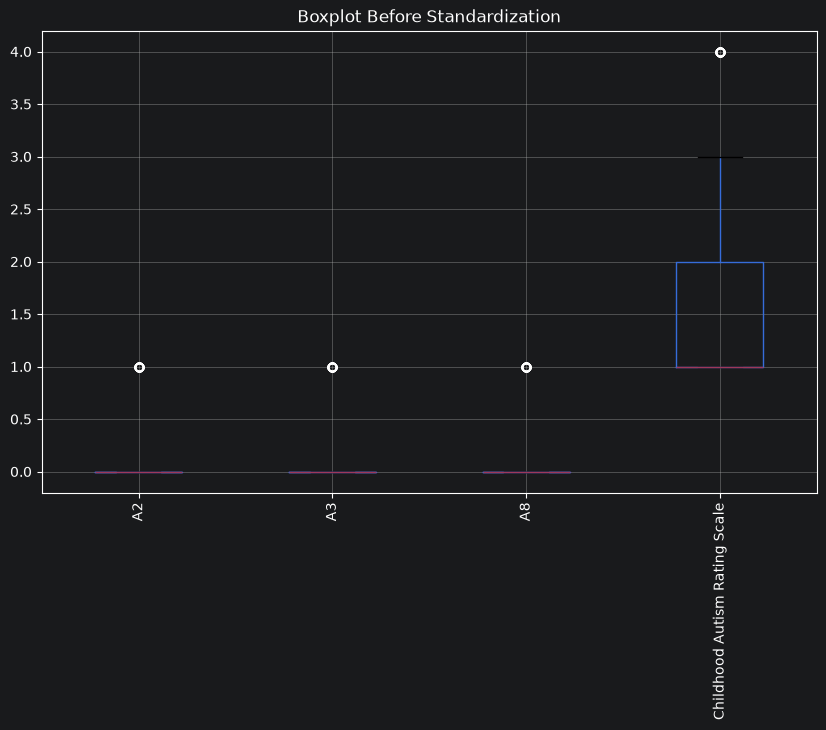

In [8]:
cols = ["A2", "A3", "A8", "Childhood Autism Rating Scale"]

# Boxplot before standardizing
df[cols].boxplot(figsize=(10, 6))
plt.title("Boxplot Before Standardization")
plt.xticks(rotation=90)
plt.show()

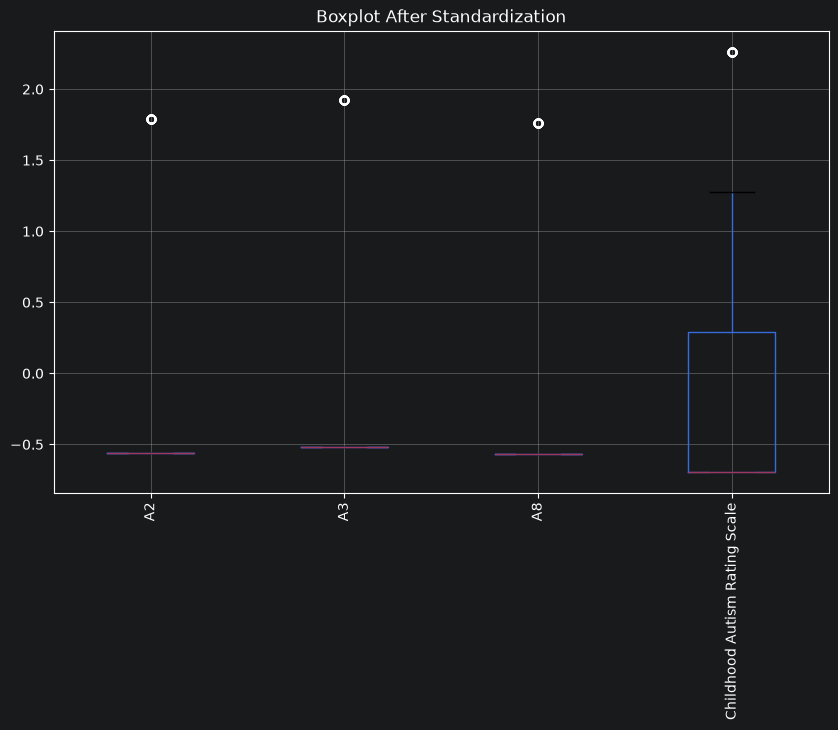

In [9]:
# Standardization
scaler = StandardScaler()
df[cols] = scaler.fit_transform(df[cols])

# Boxplot after standardizing
df[cols].boxplot(figsize=(10, 6))
plt.title("Boxplot After Standardization")
plt.xticks(rotation=90)
plt.show()

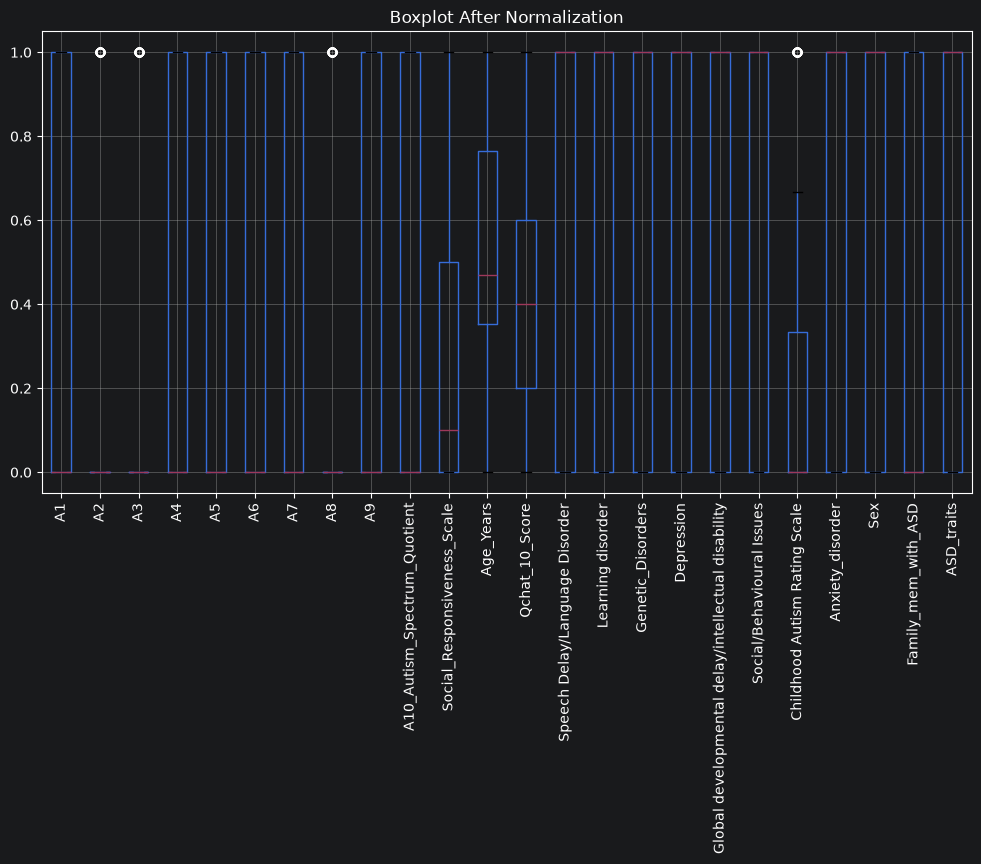

In [10]:
# Select all numeric columns (int or float), excluding IDs
id_cols = ["CASE_NO_PATIENT'S"]
cols_to_normalize = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cols_to_normalize = [col for col in cols_to_normalize if col not in id_cols]

# Apply Min-Max scaling
scaler_norm = MinMaxScaler()
df[cols_to_normalize] = scaler_norm.fit_transform(df[cols_to_normalize])

# Boxplot after normalization
df[cols_to_normalize].boxplot(figsize=(12, 6))
plt.title("Boxplot After Normalization")
plt.xticks(rotation=90)
plt.show()

In [12]:
# 8. Save final cleaned dataset
df.to_csv("data/final_cleaned.csv", index=False)
print("\nFinal cleaned dataset saved in the 'data' folder")


Final cleaned dataset saved in the 'data' folder
